<a href="https://colab.research.google.com/github/raziya85/python-basic-practice/blob/main/5_Matplotlib_and_Seaborn_for_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Matplotlib & Seaborn for Machine Learning

**Instructor:** Md. Samiul Islam | *Skill Morph Research Lab*

A practical tour of the two plotting libraries you will reach for every day as a data scientist.  
We use two real datasets — **StudentsPerformance** (tabular exam scores) and **gym_membership** (behavioural data) — to build intuition for when each chart type shines.

## 1. Setup

In [37]:
# Core stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sensible global defaults so every plot looks consistent
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['figure.dpi']     = 100

## 2. Load the Datasets

Mounting Google Drive once; both CSVs live under `MyDrive/datasets/`.

In [38]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [39]:
DATA_DIR = '/content/drive/MyDrive/datasets'

students = pd.read_csv(f'{DATA_DIR}/StudentsPerformance.csv')
gym      = pd.read_csv(f'{DATA_DIR}/gym_membership.csv')

print(f'students: {students.shape}   gym: {gym.shape}')

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/datasets/StudentsPerformance.csv'

## 3. Quick Look at the Data

Before plotting anything, always answer three questions: *what columns, what types, what scale?*

In [ ]:
students.head()

In [ ]:
students.info()

In [ ]:
students.describe()

## 4. Matplotlib — The Core Chart Types

Matplotlib is the low-level engine. Master four plot types (line, bar, scatter, histogram) and you can visualise 90% of tabular data.

### 4.1 Line Plot — trends along an order

In [ ]:
# Line plots are for *ordered* data (time, index, sequence).
# Here: math scores of the first 10 students.
scores = students['math score'].head(10)

fig, ax = plt.subplots()
ax.plot(range(1, 11), scores, marker='o')
ax.set(title='Math Scores — First 10 Students',
       xlabel='Student #', ylabel='Math Score')
plt.show()

### 4.2 Bar Chart — comparing categories

In [ ]:
# Count students by gender, plot as a bar chart.
gender_count = students['gender'].value_counts()

fig, ax = plt.subplots()
ax.bar(gender_count.index, gender_count.values, color=['#e91e63', '#2196f3'])
ax.set(title='Students by Gender', ylabel='Count')
plt.show()

In [ ]:
# Aggregated bar: average math score per gender.
avg_math = students.groupby('gender')['math score'].mean()

fig, ax = plt.subplots()
ax.bar(avg_math.index, avg_math.values, color='steelblue')
ax.set(title='Average Math Score by Gender',
       xlabel='Gender', ylabel='Avg. Math Score')
plt.show()

### 4.3 Scatter Plot — relationship between two numerics

In [ ]:
# Does reading ability track math ability? Scatter tells you at a glance.
fig, ax = plt.subplots()
ax.scatter(students['math score'], students['reading score'],
           alpha=0.4, s=18)
ax.set(title='Math vs Reading Score',
       xlabel='Math Score', ylabel='Reading Score')
plt.show()

### 4.4 Histogram — the shape of a distribution

In [ ]:
fig, ax = plt.subplots()
ax.hist(students['math score'], bins=20, color='seagreen', edgecolor='white')
ax.set(title='Distribution of Math Scores',
       xlabel='Math Score', ylabel='Frequency')
plt.show()

### 4.5 Pie Chart — parts of a whole

Use pies sparingly — only when categories are **few** and proportions **matter more than exact values**.

In [ ]:
prep = students['test preparation course'].value_counts()

fig, ax = plt.subplots()
ax.pie(prep.values, labels=prep.index, autopct='%1.1f%%',
       colors=['#ff9999', '#66b3ff'], startangle=90)
ax.set_title('Test Preparation Course')
plt.show()

### 4.6 Subplots — multiple views in one figure

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

axes[0, 0].hist(students['math score'], bins=15, color='seagreen')
axes[0, 0].set_title('Math Score Distribution')

students['gender'].value_counts().plot(kind='bar', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Gender Count')

axes[1, 0].scatter(students['math score'].head(50),
                   students['reading score'].head(50), alpha=0.6)
axes[1, 0].set(title='Math vs Reading (sample=50)',
               xlabel='Math', ylabel='Reading')

axes[1, 1].plot(students['writing score'].head(30), color='darkorange')
axes[1, 1].set_title('Writing Scores — First 30 Students')

plt.tight_layout()
plt.show()

## 5. Seaborn — Statistical Plots, Less Code

Seaborn is built on Matplotlib but understands DataFrames. You pass column names instead of arrays, and it handles grouping, aggregation, and styling for you.

### 5.1 `histplot` — distribution with an optional KDE

In [ ]:
fig, ax = plt.subplots()
sns.histplot(students['math score'], bins=20, kde=True, ax=ax)
ax.set_title('Math Score — Histogram + KDE')
plt.show()

### 5.2 `boxplot` — compare distributions across groups

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(data=students, x='gender', y='math score', ax=axes[0])
axes[0].set_title('Math Score by Gender')

sns.boxplot(data=students, x='lunch', y='math score', ax=axes[1])
axes[1].set_title('Math Score by Lunch Type')

plt.tight_layout()
plt.show()

### 5.3 `countplot` — frequency of categorical values

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(data=students, x='race/ethnicity', ax=axes[0])
axes[0].set_title('Race / Ethnicity')

sns.countplot(data=students, x='test preparation course', ax=axes[1])
axes[1].set_title('Test Preparation')

plt.tight_layout()
plt.show()

### 5.4 `barplot` — category-wise mean with confidence interval

Unlike `plt.bar`, Seaborn's `barplot` aggregates automatically and draws error bars.

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
order = students.groupby('parental level of education')['math score'].mean().sort_values().index
sns.barplot(data=students, x='parental level of education',
            y='math score', order=order, ax=ax)
ax.set_title('Average Math Score by Parental Education')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

### 5.5 `kdeplot` — smooth distribution, great for overlays

In [ ]:
fig, ax = plt.subplots()
sns.kdeplot(data=students, x='math score', hue='gender', fill=True, ax=ax)
ax.set_title('Math Score Density by Gender')
plt.show()

### 5.6 `heatmap` — correlation matrix at a glance

A correlation heatmap is the single fastest way to spot relationships between numeric features.

In [ ]:
corr = students[['math score', 'reading score', 'writing score']].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1,
            fmt='.2f', ax=ax)
ax.set_title('Score Correlations')
plt.show()

### 5.7 `pairplot` — every numeric pair at once

`pairplot` returns its own figure (don't wrap it in `subplots`). Add `hue` to colour by a category.

In [ ]:
sns.pairplot(students[['math score', 'reading score', 'writing score', 'gender']],
             hue='gender', height=2.2)
plt.show()

## 6. A Reusable EDA Function

In real projects you repeat the same six or seven plots on every new dataset. Wrap them in a function — one line of code, full visual summary.

In [ ]:
def quick_eda(df):
    """Six-panel EDA summary for the students dataframe."""
    fig, axes = plt.subplots(2, 3, figsize=(13, 7))

    axes[0, 0].hist(df['math score'], bins=20, color='seagreen')
    axes[0, 0].set_title('Math Score')

    df['gender'].value_counts().plot(kind='bar', ax=axes[0, 1], color='steelblue')
    axes[0, 1].set_title('Gender')

    prep = df['test preparation course'].value_counts()
    axes[0, 2].pie(prep.values, labels=prep.index, autopct='%1.0f%%')
    axes[0, 2].set_title('Test Prep')

    axes[1, 0].scatter(df['math score'], df['reading score'], alpha=0.3)
    axes[1, 0].set(title='Math vs Reading', xlabel='Math', ylabel='Reading')

    df.groupby('lunch')['math score'].mean().plot(kind='bar', ax=axes[1, 1], color='coral')
    axes[1, 1].set_title('Lunch Effect on Math')

    df[['math score', 'reading score', 'writing score']].mean().plot(
        kind='bar', ax=axes[1, 2], color='slateblue')
    axes[1, 2].set_title('Average Scores')

    plt.tight_layout()
    plt.show()

quick_eda(students)

## 7. Practice — Gym Membership Dataset

Apply the same toolkit to a different dataset. First, inspect; then, visualise.

In [ ]:
gym.head()

In [ ]:
print('Missing values in gym dataset:')
display(gym.isnull().sum())

In [ ]:
print('Shape   :', gym.shape)
print('Columns :', gym.columns.tolist())
gym.dtypes

In [ ]:
# 4-panel snapshot of the gym data
fig, axes = plt.subplots(2, 2, figsize=(11, 7))

axes[0, 0].hist(gym['Age'], bins=20, color='seagreen')
axes[0, 0].set_title('Age Distribution')

gym['gender'].value_counts().plot(kind='bar', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('Gender')

axes[1, 0].hist(gym['visit_per_week'], bins=10, color='coral')
axes[1, 0].set_title('Visits per Week')

gym['personal_training'].value_counts().plot(
    kind='pie', ax=axes[1, 1], autopct='%1.0f%%', ylabel='')
axes[1, 1].set_title('Personal Training')

plt.tight_layout()
plt.show()

## 8. Hands-on Exercises

Try these on your own — solutions follow the same patterns you just saw above.

**Matplotlib**
1. Bar chart of membership types — `gym['abonoment_type'].value_counts()`
2. Histogram of `avg_time_in_gym`
3. Scatter plot of `Age` vs `visit_per_week`

**Seaborn**
1. Box plot — `gender` vs `Age`
2. Count plot — `days_per_week`
3. Bar plot — mean `visit_per_week` per `abonoment_type`

In [ ]:
# Your code here


In [ ]:
# Core stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sensible global defaults so every plot looks consistent
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.figsize'] = (7, 4)
plt.rcParams['figure.dpi']     = 100

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [46]:
file_path = '/content/drive/MyDrive/gym_membership.csv'

In [47]:
gym = pd.read_csv(file_path)
print(f'gym: {gym.shape}')

gym: (1000, 17)


In [48]:
gym.head()

,id,gender,birthday,Age,abonoment_type,visit_per_week,days_per_week,attend_group_lesson,fav_group_lesson,avg_time_check_in,avg_time_check_out,avg_time_in_gym,drink_abo,fav_drink,personal_training,name_personal_trainer,uses_sauna
0,1,Female,4/18/1997,27,Premium,4,"Mon, Sat, Tue, Wed",True,"Kickboxen, BodyPump, Zumba",19:31:00,21:27:00,116,False,NaN,False,NaN,True
1,2,Female,9/18/1977,47,Standard,3,"Mon, Sat, Wed",False,NaN,19:31:00,20:19:00,48,False,NaN,True,Chantal,False
2,3,Male,3/30/1983,41,Premium,1,Sat,True,XCore,8:29:00,10:32:00,123,True,"berry_boost, lemon",True,Mike,False
3,4,Male,4/12/1980,44,Premium,3,"Sat, Tue, Wed",False,NaN,9:54:00,11:33:00,99,True,passion_fruit,True,Mike,True
4,5,Male,9/10/1980,44,Standard,2,"Thu, Wed",True,"Running, Yoga, Zumba",8:29:00,9:19:00,50,False,NaN,True,Mike,False


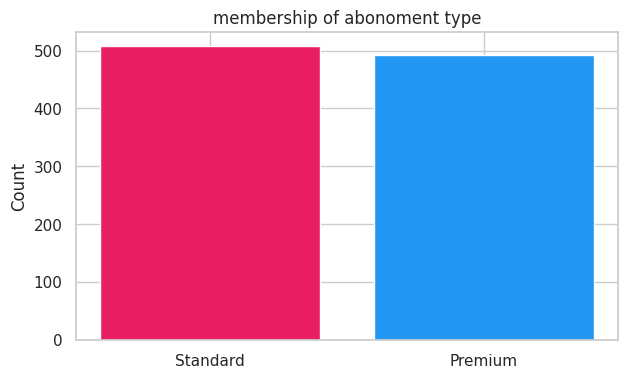

In [44]:
#Bar chart of membership types — gym['abonoment_type'].value_counts()
abonoment_count = gym['abonoment_type'].value_counts()
fig, ax = plt.subplots()
ax.bar(abonoment_count.index, abonoment_count.values, color=['#e91e63', '#2196f3'])
ax.set(title='membership of abonoment type', ylabel='Count')
plt.show()

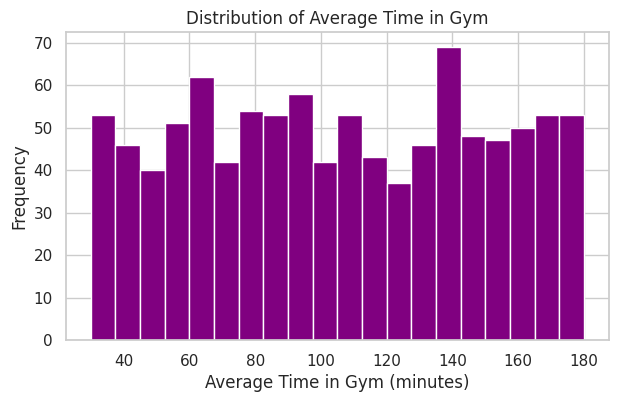

In [43]:
#Histogram of avg_time_in_gym

fig, ax = plt.subplots()
ax.hist(gym['avg_time_in_gym'], bins=20, color='purple', edgecolor='white')
ax.set(title='Distribution of Average Time in Gym',
       xlabel='Average Time in Gym (minutes)', ylabel='Frequency')
plt.show()

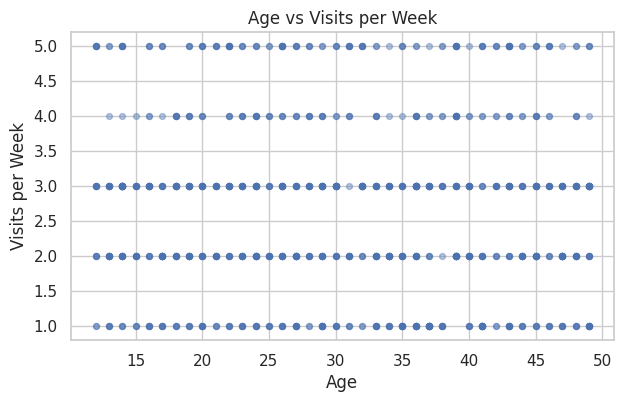

In [42]:
#Scatter plot of Age vs visit_per_week

fig, ax = plt.subplots()
ax.scatter(gym['Age'], gym['visit_per_week'],
           alpha=0.4, s=18)
ax.set(title='Age vs Visits per Week',
       xlabel='Age', ylabel='Visits per Week')
plt.show()

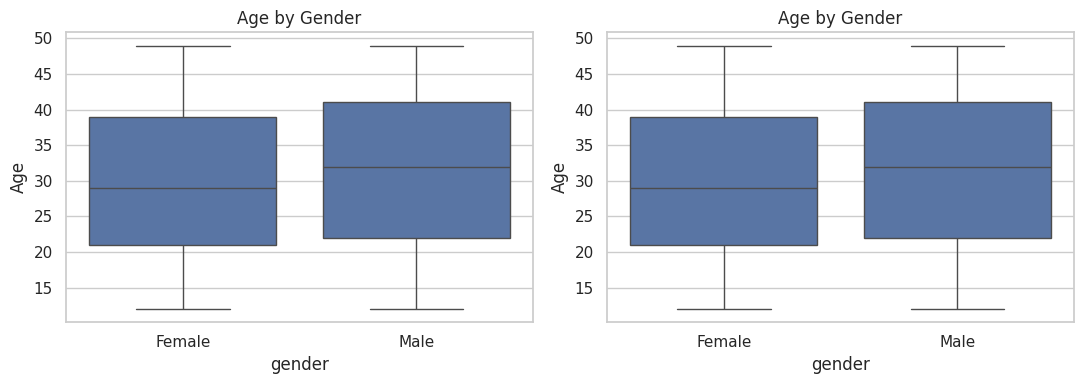

In [41]:
#Box plot — gender vs Age

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.boxplot(data=gym, x='gender', y='Age', ax=axes[0])
axes[0].set_title('Age by Gender')

sns.boxplot(data=gym, x='gender', y='Age', ax=axes[1])
axes[1].set_title('Age by Gender')

plt.tight_layout()
plt.show()

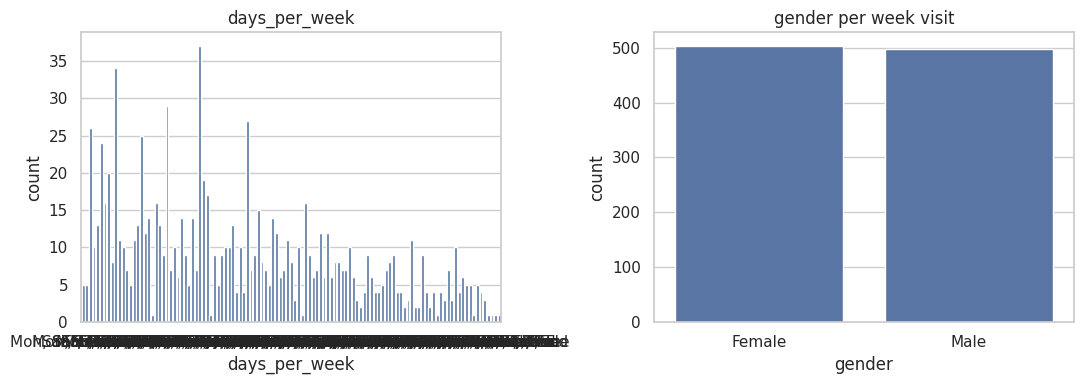

In [49]:
#Count plot — days_per_week

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

sns.countplot(data=gym, x='days_per_week', ax=axes[0])
axes[0].set_title('days_per_week')

sns.countplot(data=gym, x='gender', ax=axes[1])
axes[1].set_title('gender per week visit')

plt.tight_layout()
plt.show()


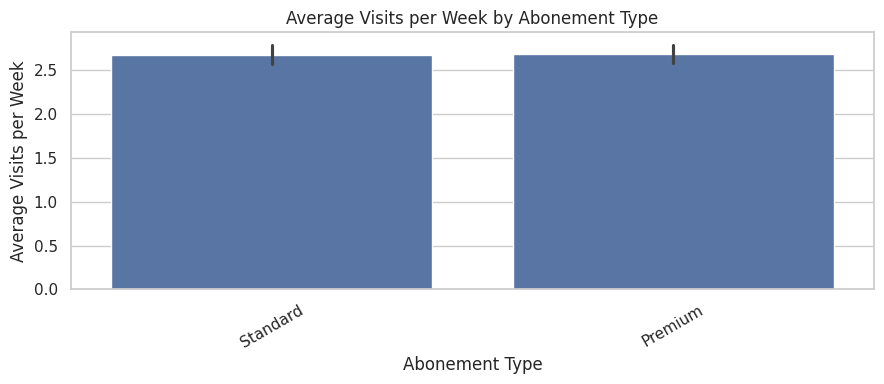

In [40]:
#Bar plot — mean visit_per_week per abonoment_type

fig, ax = plt.subplots(figsize=(9, 4))
order = gym.groupby('abonoment_type')['visit_per_week'].mean().sort_values().index
sns.barplot(data=gym, x='abonoment_type',
            y='visit_per_week', order=order, ax=ax)
ax.set_title('Average Visits per Week by Abonement Type')
ax.set_xlabel('Abonement Type')
ax.set_ylabel('Average Visits per Week')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

---
*End of notebook — Md. Samiul Islam, Skill Morph Research Lab.*